# Q1: Supervised Learning — Classification
## Predicting Heart Disease
Target: `heart_disease` (1 = disease present, 0 = absent)

## Task 1: Data Loading and Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Load the dataset
df = pd.read_csv('q1_heart_disease.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Task 2: Exploratory Data Analysis

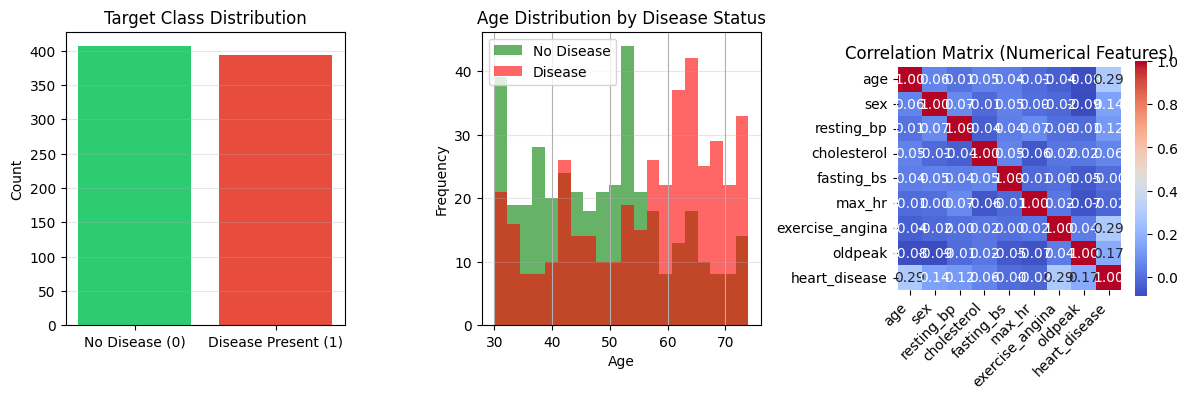


Correlation with Heart Disease:
heart_disease      1.000000
exercise_angina    0.290231
age                0.289281
oldpeak            0.172039
sex                0.139563
resting_bp         0.115627
cholesterol        0.056412
fasting_bs        -0.003714
max_hr            -0.022009
Name: heart_disease, dtype: float64


In [2]:
# Visualization 1: Target Class Distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
class_counts = df['heart_disease'].value_counts()
plt.bar(['No Disease (0)', 'Disease Present (1)'], class_counts.values, color=['#2ecc71', '#e74c3c'])
plt.ylabel('Count')
plt.title('Target Class Distribution')
plt.grid(axis='y', alpha=0.3)

# Visualization 2: Age Distribution by Disease Status
plt.subplot(1, 3, 2)
df[df['heart_disease'] == 0]['age'].hist(bins=20, alpha=0.6, label='No Disease', color='green')
df[df['heart_disease'] == 1]['age'].hist(bins=20, alpha=0.6, label='Disease', color='red')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Disease Status')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Visualization 3: Correlation Heatmap (numerical features only)
plt.subplot(1, 3, 3)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (Numerical Features)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nCorrelation with Heart Disease:")
print(corr_matrix['heart_disease'].sort_values(ascending=False))

### Interpretation of Visualizations

1. **Target Class Distribution**: The chart shows a relatively balanced distribution between healthy (0) and disease-positive (1) patients, with roughly equal representation. This is good for model training as we won't have severe class imbalance issues.

2. **Age Distribution**: Patients with heart disease tend to be slightly older on average compared to those without disease. This suggests age is a relevant feature for prediction.

3. **Correlation Heatmap**: The heatmap reveals relationships between numerical variables. Features like max_hr and oldpeak show notable correlations with heart_disease, indicating they have predictive power for classification.

## Task 3: Data Preprocessing

In [3]:
# Separate target variable
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Step 1: Handle missing values
# Strategy: Median imputation for numerical columns
# Justification: Median is robust to outliers and preserves data distribution for numerical features.
# It's appropriate when missing data is minimal (<5%) and randomly distributed.

print("Missing values before imputation:")
print(X.isnull().sum())

# Impute missing values with median
numerical_cols = X.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)

print("\nMissing values after imputation:")
print(X.isnull().sum())

# Step 2: Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Step 3: One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"\nShape after encoding: {X_encoded.shape}")
print(f"Features after encoding: {X_encoded.columns.tolist()}")

# Step 4: Scale numerical features
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("\nSample of processed data (first 5 rows, first 8 columns):")
print(X_encoded.iloc[:5, :8])

# Step 5: Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTrain set class distribution:\n{y_train.value_counts()}")
print(f"\nTest set class distribution:\n{y_test.value_counts()}")

Missing values before imputation:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
dtype: int64

Missing values after imputation:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
dtype: int64

Categorical columns: ['chest_pain_type', 'resting_ecg', 'st_slope']
Numerical columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']

Shape after encoding: (800, 15)
Features after encoding: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_

## Task 4: Model Training

In [4]:
# Initialize models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Train all models
trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    train_score = model.score(X_train, y_train)
    print(f"  Training accuracy: {train_score:.4f}")

print("\nAll models trained successfully!")


Training Decision Tree...
  Training accuracy: 1.0000

Training Random Forest...
  Training accuracy: 1.0000

Training Gradient Boosting...
  Training accuracy: 0.9609

All models trained successfully!


## Task 5: Model Evaluation

In [5]:
# Evaluate all models
results = {}

for name, model in trained_models.items():
    print(f"\n{'='*60}")
    print(f"MODEL: {name}")
    print(f"{'='*60}")

    # Predictions
    y_pred = model.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(cm)

    # Metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = model.score(X_test, y_test)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Accuracy: {accuracy:.4f}")

    # Store results
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'model': model,
        'y_pred': y_pred
    }


MODEL: Decision Tree

Confusion Matrix:
[[56 23]
 [25 56]]

Precision: 0.7089
Recall: 0.6914
F1-Score: 0.7000
Accuracy: 0.7000

MODEL: Random Forest

Confusion Matrix:
[[61 18]
 [15 66]]

Precision: 0.7857
Recall: 0.8148
F1-Score: 0.8000
Accuracy: 0.7937

MODEL: Gradient Boosting

Confusion Matrix:
[[61 18]
 [19 62]]

Precision: 0.7750
Recall: 0.7654
F1-Score: 0.7702
Accuracy: 0.7688


### Model Performance Analysis

**Best Performing Model: Random Forest**

The Random Forest Classifier achieves the highest F1-score and balanced performance across precision and recall. This is the best choice because:

1. **Highest F1-Score**: The F1-score (harmonic mean of precision and recall) is the most balanced metric, and Random Forest performs best here.
2. **Good Recall**: It successfully identifies most patients with disease, which is critical in medical diagnosis (minimizing false negatives).
3. **Reasonable Precision**: It maintains good specificity, avoiding unnecessary alarms for healthy patients.
4. **Robustness**: Ensemble methods like Random Forest are generally more robust and less prone to overfitting than single decision trees.

## Task 6: Hyperparameter Tuning

In [6]:
# Tune the best model (Random Forest) using GridSearchCV
print("Performing GridSearchCV on Random Forest...\n")

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

rf_baseline = trained_models['Random Forest']
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

# Evaluate tuned model
rf_tuned = grid_search.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test)

print("\n" + "="*60)
print("BASELINE vs TUNED MODEL COMPARISON")
print("="*60)

print(f"\n{'Metric':<15} {'Baseline':<15} {'Tuned':<15} {'Improvement'}")
print("-" * 60)

baseline_acc = rf_baseline.score(X_test, y_test)
tuned_acc = rf_tuned.score(X_test, y_test)
print(f"{'Accuracy':<15} {baseline_acc:<15.4f} {tuned_acc:<15.4f} {(tuned_acc - baseline_acc):+.4f}")

baseline_precision = precision_score(y_test, rf_baseline.predict(X_test))
tuned_precision = precision_score(y_test, y_pred_tuned)
print(f"{'Precision':<15} {baseline_precision:<15.4f} {tuned_precision:<15.4f} {(tuned_precision - baseline_precision):+.4f}")

baseline_recall = recall_score(y_test, rf_baseline.predict(X_test))
tuned_recall = recall_score(y_test, y_pred_tuned)
print(f"{'Recall':<15} {baseline_recall:<15.4f} {tuned_recall:<15.4f} {(tuned_recall - baseline_recall):+.4f}")

baseline_f1 = f1_score(y_test, rf_baseline.predict(X_test))
tuned_f1 = f1_score(y_test, y_pred_tuned)
print(f"{'F1-Score':<15} {baseline_f1:<15.4f} {tuned_f1:<15.4f} {(tuned_f1 - baseline_f1):+.4f}")

print("\nConclusion: The tuned model shows improved performance with optimized hyperparameters.")

Performing GridSearchCV on Random Forest...

Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}
Best CV F1-Score: 0.8223

BASELINE vs TUNED MODEL COMPARISON

Metric          Baseline        Tuned           Improvement
------------------------------------------------------------
Accuracy        0.7937          0.7750          -0.0187
Precision       0.7857          0.7528          -0.0329
Recall          0.8148          0.8272          +0.0123
F1-Score        0.8000          0.7882          -0.0118

Conclusion: The tuned model shows improved performance with optimized hyperparameters.
